**Part-2: Vision Tasks**

**Image Classification with Convolutional Neural Network.**

In [108]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [109]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [110]:
# Dataset path
train_path = "/content/drive/MyDrive/AI and Machine Learning/Brain Tumor Classifcation/train"
test_path = "/content/drive/MyDrive/AI and Machine Learning/Brain Tumor Classifcation/test"

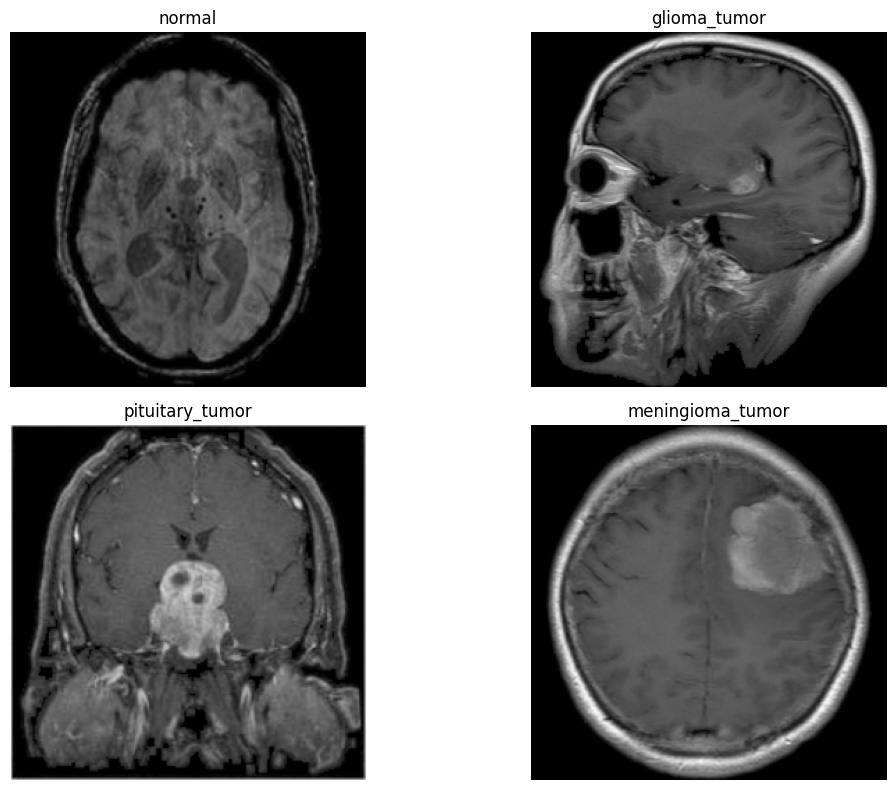

In [111]:
# Display sample images from each category
plt.figure(figsize=(12, 8))
classes = os.listdir(train_path)

for i, category in enumerate(classes):
    folder_path = os.path.join(train_path, category)
    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [112]:
# Apply data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Test data should only be normalized
test_datagen = ImageDataGenerator(rescale=1./255)

In [113]:
# Load training dataset
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 1960 images belonging to 4 classes.


In [114]:
# Load validation dataset
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 487 images belonging to 4 classes.


In [115]:
# Load test dataset
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 621 images belonging to 4 classes.


CNN Model from Scratch

In [116]:
# Build CNN model
cnn_model = Sequential()

# First convolution block
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Second convolution block
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Third convolution block
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Flatten layer
cnn_model.add(Flatten())

# Dense layer
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))

# Output layer
cnn_model.add(Dense(4, activation='softmax'))

In [117]:
# Display model architecture
cnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

Compile CNN Model

In [118]:
# Compile the CNN model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Add Early Stopping to prevent overfitting

In [119]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Train and Evaluate CNN Model

In [120]:
# Train CNN model
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 62s 732ms/step - accuracy: 0.3128 - loss: 5.0735 - val_accuracy: 0.2977 - val_loss: 14.2911
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 682ms/step - accuracy: 0.3306 - loss: 1.7350 - val_accuracy: 0.3244 - val_loss: 11.3987
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 682ms/step - accuracy: 0.3291 - loss: 1.5262 - val_accuracy: 0.2916 - val_loss: 41.4285
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 715ms/step - accuracy: 0.3143 - loss: 1.3298 - val_accuracy: 0.2793 - val_loss: 21.0593
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 654ms/step - accuracy: 0.3474 - loss: 1.2889 - val_accuracy: 0.3244 - val_loss: 16.0744
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 659ms/step - accuracy: 0.3526 - loss: 1.2879 - val_accuracy: 0.3634 - val_loss: 1.5749
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 84s 691ms/step - accuracy: 0.3765 - loss: 1.2579 - val_accuracy: 0.3224 - val_loss: 2.4644
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 721ms/step - accuracy: 0.3888 - loss: 1.2572 - val

In [121]:
# Evaluate CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_generator)

print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.3849 - loss: 1.4358
CNN Test Accuracy: 0.38486313819885254
CNN Test Loss: 1.4358153343200684


Plot Accuracy Graph

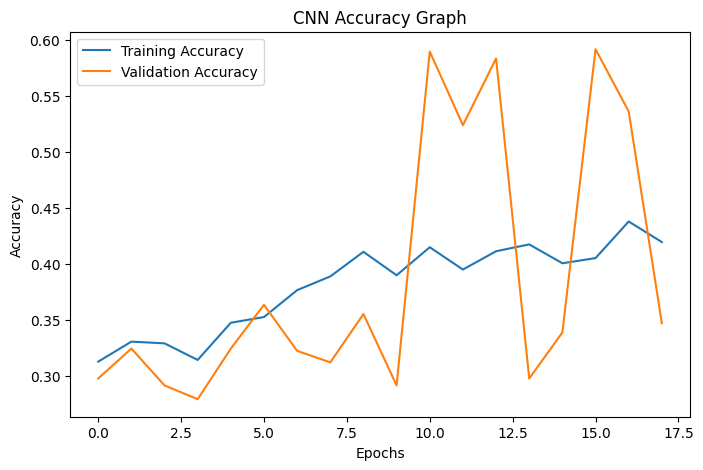

In [122]:
# Plot training and validation accuracy
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Loss Graph

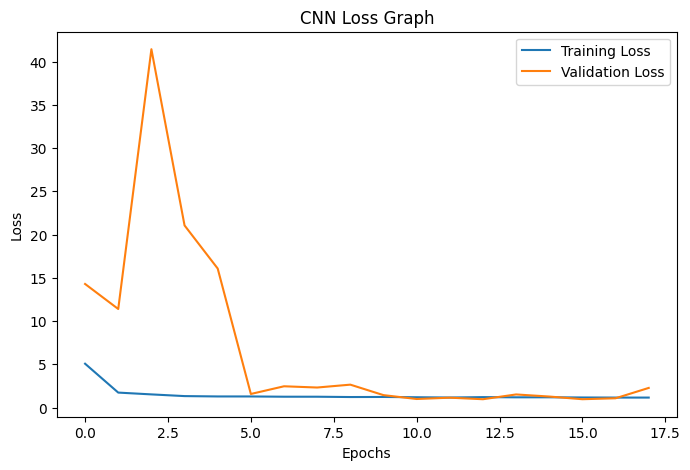

In [123]:
# Plot training and validation loss
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [124]:
# Generate predictions
predictions = cnn_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step


In [125]:
# Display classification report
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

                  precision    recall  f1-score   support

    glioma_tumor       0.61      0.08      0.14       181
meningioma_tumor       0.41      0.32      0.36       183
          normal       0.60      0.03      0.06        88
 pituitary_tumor       0.36      0.97      0.53       169

        accuracy                           0.38       621
       macro avg       0.50      0.35      0.27       621
    weighted avg       0.48      0.38      0.30       621



Confusion Matrix

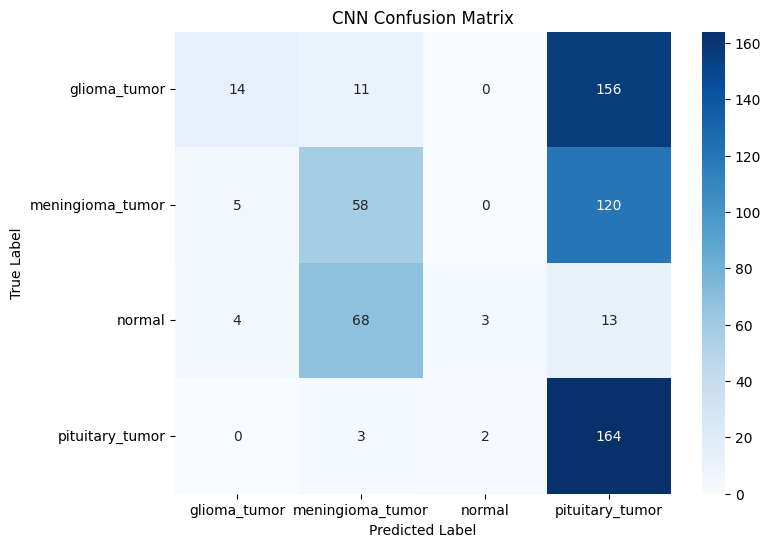

In [126]:
# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')

plt.show()

Transfer Learning Using MobileNetV2

In [127]:
# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

In [128]:
# Build transfer learning model
transfer_model = Sequential([
    base_model,

    # Convert feature maps into vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # Fully connected layer
    Dense(128, activation='relu'),

    # Dropout for overfitting reduction
    Dropout(0.4),

    # Output layer
    Dense(4, activation='softmax')
])

In [129]:
# Display transfer learning architecture
transfer_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [130]:
# Compile transfer learning model
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [131]:
# Train transfer learning model
transfer_history = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 64s 884ms/step - accuracy: 0.6332 - loss: 0.8870 - val_accuracy: 0.7187 - val_loss: 0.7267
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 657ms/step - accuracy: 0.7612 - loss: 0.6165 - val_accuracy: 0.7782 - val_loss: 0.5834
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 653ms/step - accuracy: 0.7918 - loss: 0.5440 - val_accuracy: 0.8193 - val_loss: 0.5099
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 651ms/step - accuracy: 0.8061 - loss: 0.4988 - val_accuracy: 0.7988 - val_loss: 0.5228
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 636ms/step - accuracy: 0.8276 - loss: 0.4827 - val_accuracy: 0.7782 - val_loss: 0.5823
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 638ms/step - accuracy: 0.8204 - loss: 0.4529 - val_accuracy: 0.8316 - val_loss: 0.4195
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 653ms/step - accuracy: 0.8372 - loss: 0.4221 - val_accuracy: 0.8193 - val_loss: 0.4462
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 645ms/step - accuracy: 0.8418 - loss: 0.4127 - val_accu

In [132]:
# Evaluate transfer learning model
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_generator)

print("Transfer Learning Accuracy:", transfer_accuracy)
print("Transfer Learning Loss:", transfer_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 376ms/step - accuracy: 0.7971 - loss: 0.4998
Transfer Learning Accuracy: 0.7971014380455017
Transfer Learning Loss: 0.49978169798851013


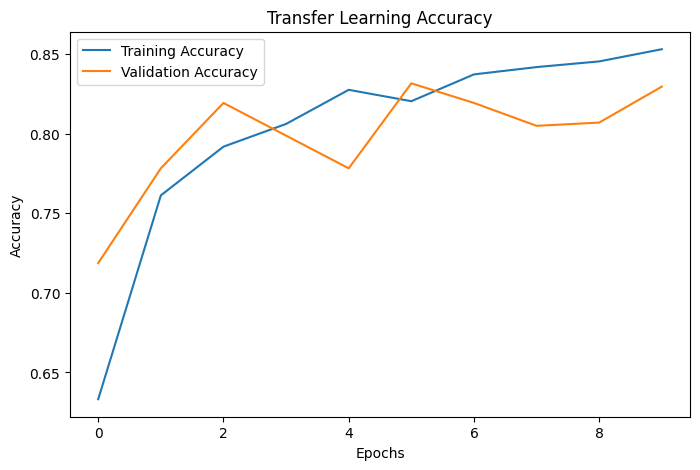

In [133]:
# Plot transfer learning accuracy graph
plt.figure(figsize=(8,5))

plt.plot(transfer_history.history['accuracy'], label='Training Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Transfer Learning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

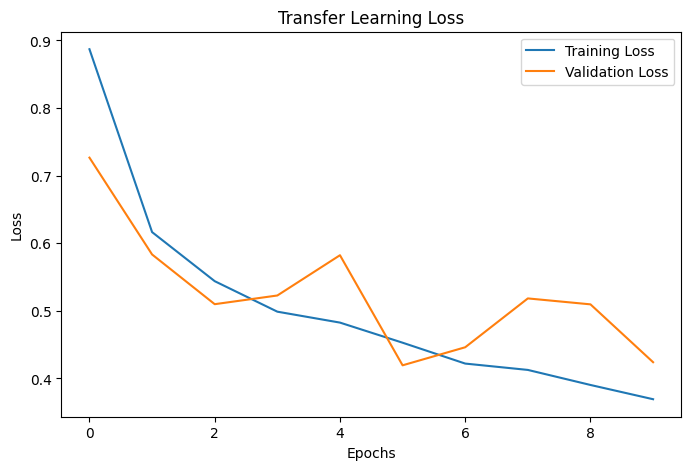

In [134]:
# Plot transfer learning loss graph
plt.figure(figsize=(8,5))

plt.plot(transfer_history.history['loss'], label='Training Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')

plt.title('Transfer Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Comparison of CNN and Transfer Learning

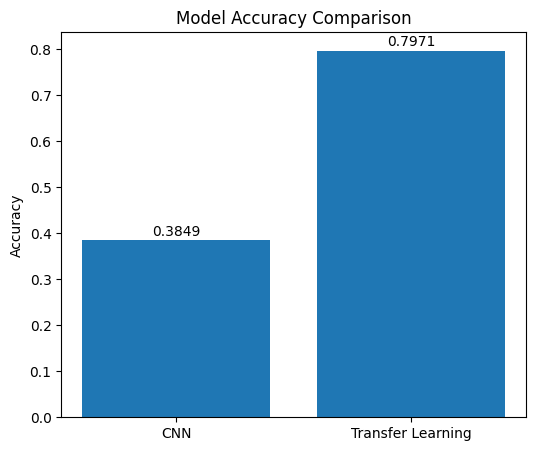

In [135]:
# Compare both models
models = ['CNN', 'Transfer Learning']
accuracies = [cnn_accuracy, transfer_accuracy]

plt.figure(figsize=(6,5))

bars = plt.bar(models, accuracies)

# Add accuracy values above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        round(yval, 4),
        ha='center'
    )

plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.show()

Test model on random images

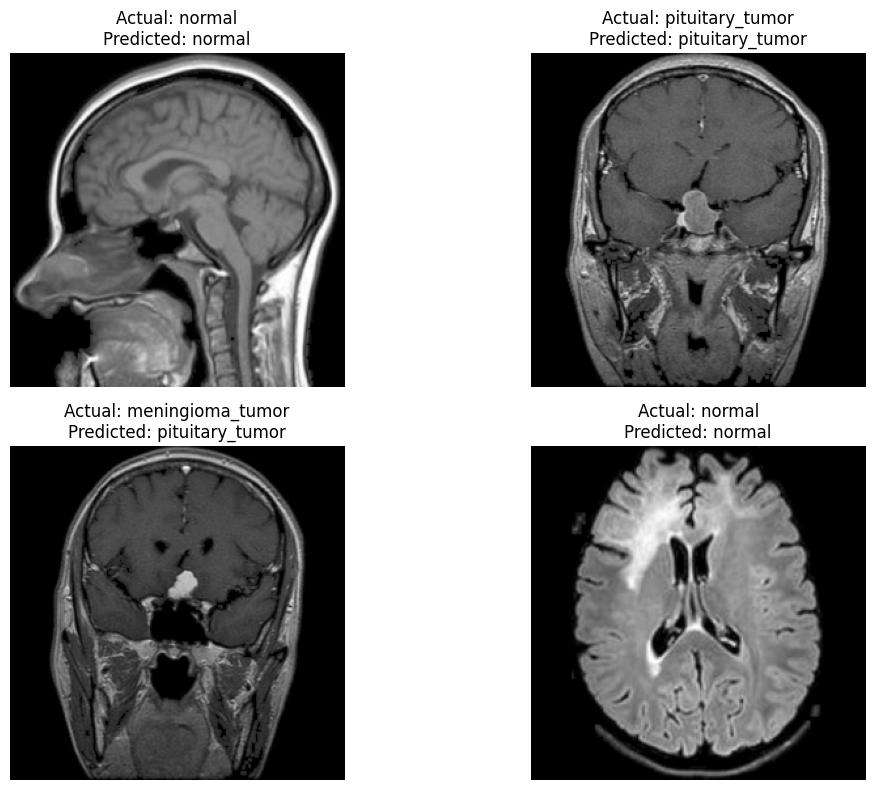

In [136]:
import random

# Select random test images
random_images = random.sample(test_generator.filepaths, 4)

plt.figure(figsize=(12,8))

for i, image_path in enumerate(random_images):

    # Read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    resized_img = cv2.resize(img, (224,224))

    # Normalize image
    normalized_img = resized_img / 255.0

    # Expand dimensions
    input_img = np.expand_dims(normalized_img, axis=0)

    # Make prediction
    prediction = transfer_model.predict(input_img, verbose=0)

    predicted_class = class_labels[np.argmax(prediction)]

    # Actual class
    actual_class = image_path.split('/')[-2]

    # Plot image
    plt.subplot(2,2,i+1)
    plt.imshow(img)

    plt.title(
        f"Actual: {actual_class}\nPredicted: {predicted_class}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [137]:
# Save CNN model
cnn_model.save("brain_tumor_cnn_model.keras")

# Save transfer learning model
transfer_model.save("brain_tumor_transfer_model.keras")

print("Models saved successfully!")

Models saved successfully!


# Conclusio
Both a CNN model and a Transfer Learning model were developed for brain tumor classification using MRI images.
The CNN model successfully learned image features using convolution and pooling layers. Data augmentation and dropout helped reduce overfitting and improved model generalization.
Transfer Learning using MobileNetV2 achieved better performance because pretrained models already contain useful image feature representations learned from large datasets.
The comparison showed that transfer learning provides faster convergence and higher classification accuracy than the CNN model trained from scratch.
Overall, deep learning techniques can effectively support automated brain tumor detection and classification in medical imaging applications.